데이터 생성 중...
모델 학습 시작...
Epoch [20/200], Loss: 0.000029
Epoch [40/200], Loss: 0.000025
Epoch [60/200], Loss: 0.000020
Epoch [80/200], Loss: 0.000024
Epoch [100/200], Loss: 0.000023
Epoch [120/200], Loss: 0.000029
Epoch [140/200], Loss: 0.000014
Epoch [160/200], Loss: 0.000014
Epoch [180/200], Loss: 0.000009
Epoch [200/200], Loss: 0.000012
모델 평가 중...


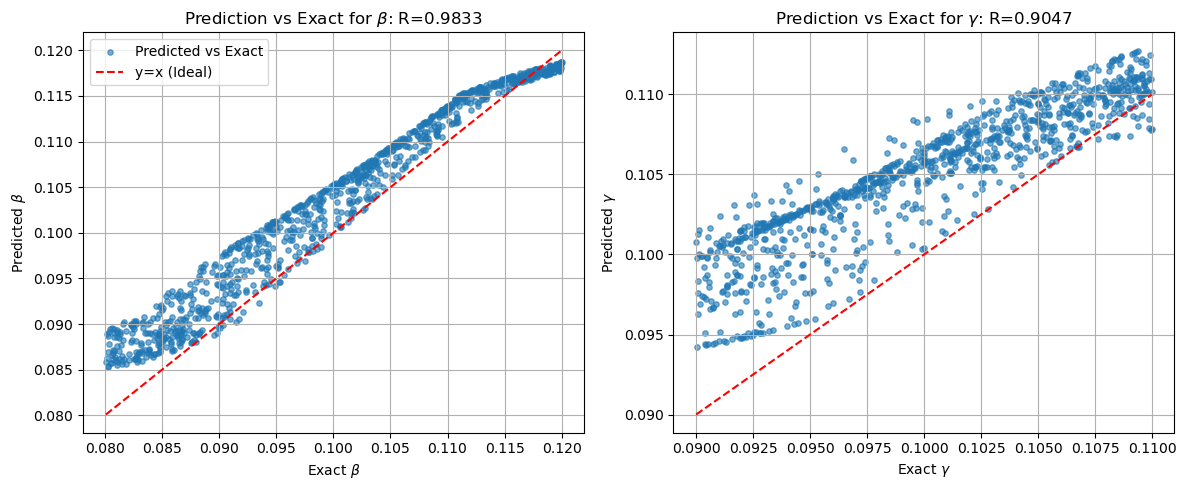

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- 1. 데이터 생성 (ODE Simulator) ---
# SIR 모델의 상미분방정식을 정의합니다.
def sir_model(t, y, beta, gamma, N):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# 시뮬레이션 데이터를 생성하는 함수입니다.
def generate_sir_data(num_samples=2000):
    """
    무작위 beta, gamma 쌍에 대해 SIR 모델을 시뮬레이션하고,
    희소한 S(t) 관측 데이터와 실제 파라미터를 반환합니다.
    """
    # 논문과 유사한 파라미터 범위 설정 [cite: 158]
    beta_range = [0.08, 0.12]
    gamma_range = [0.09, 0.11]
    
    # 관측 시점 설정 [cite: 86]
    observation_times = np.array([0, 20, 40, 60, 80, 100])
    
    X_data = [] # 관측 데이터 (입력)
    y_data = [] # 실제 파라미터 (정답)

    for _ in range(num_samples):
        # 1. 파라미터 샘플링
        beta = np.random.uniform(*beta_range)
        gamma = np.random.uniform(*gamma_range)
        
        # 2. 초기 조건 설정 [cite: 66, 67, 68, 69]
        N0 = 50.0
        I0 = 1.0
        R0 = 0.0
        S0 = N0 - I0 - R0
        y0 = [S0, I0, R0]
        
        # 3. ODE 풀이
        sol = solve_ivp(
            fun=sir_model,
            t_span=[0, 110],
            y0=y0,
            args=(beta, gamma, N0),
            dense_output=True
        )
        
        # 4. 희소 데이터 추출 (S(t)만 관측)
        s_observed = sol.sol(observation_times)[0]
        
        X_data.append(s_observed)
        y_data.append([beta, gamma])
        
    return np.array(X_data), np.array(y_data)

# --- 2. 모델 정의 ---
# 논문의 Figure 3을 모사한 간단한 FFNN 모델 [cite: 177, 189]
class ParameterEstimator(nn.Module):
    def __init__(self):
        super(ParameterEstimator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(6, 64), # 입력: 6개 시점의 S(t) 값 [cite: 174]
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # 출력: beta, gamma 2개 값 [cite: 175, 176]
        )

    def forward(self, x):
        return self.network(x)

# --- 3. 학습 및 평가 ---
if __name__ == '__main__':
    # 하이퍼파라미터
    NUM_SAMPLES = 5000
    TEST_SPLIT = 0.2
    BATCH_SIZE = 64
    EPOCHS = 200
    LEARNING_RATE = 1e-3
    
    # 1. 데이터셋 생성 및 준비
    print("데이터 생성 중...")
    X, y = generate_sir_data(NUM_SAMPLES)
    
    # 데이터를 Tensor로 변환
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    
    # 데이터셋 분할 (Train/Test)
    dataset = TensorDataset(X_tensor, y_tensor)
    train_size = int((1 - TEST_SPLIT) * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
    
    # 2. 모델, 손실함수, 옵티마이저 초기화
    model = ParameterEstimator()
    loss_fn = nn.MSELoss()  # L2 Loss [cite: 190, 193]
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # 3. 학습 루프
    print("모델 학습 시작...")
    for epoch in range(EPOCHS):
        model.train()
        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.6f}")

    # 4. 평가
    print("모델 평가 중...")
    model.eval()
    all_y_true = []
    all_y_pred = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            all_y_true.append(y_batch.numpy())
            all_y_pred.append(y_pred.numpy())

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)
    
    # 5. 결과 시각화 (논문의 Figure 4와 같은 형태) [cite: 206]
    plt.style.use('default')
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Beta 예측 결과
    r_beta = np.corrcoef(y_true[:, 0], y_pred[:, 0])[0, 1]
    axes[0].scatter(y_true[:, 0], y_pred[:, 0], alpha=0.6, s=15, label=f'Predicted vs Exact')
    axes[0].plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--', label='y=x (Ideal)')
    axes[0].set_xlabel("Exact $\\beta$")
    axes[0].set_ylabel("Predicted $\\beta$")
    axes[0].set_title(f"Prediction vs Exact for $\\beta$: R={r_beta:.4f}")
    axes[0].grid(True)
    axes[0].legend()
    
    # Gamma 예측 결과
    r_gamma = np.corrcoef(y_true[:, 1], y_pred[:, 1])[0, 1]
    axes[1].scatter(y_true[:, 1], y_pred[:, 1], alpha=0.6, s=15)
    axes[1].plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    axes[1].set_xlabel("Exact $\\gamma$")
    axes[1].set_ylabel("Predicted $\\gamma$")
    axes[1].set_title(f"Prediction vs Exact for $\\gamma$: R={r_gamma:.4f}")
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

데이터 생성 중...
모델 학습 시작...


모델 평가 중...


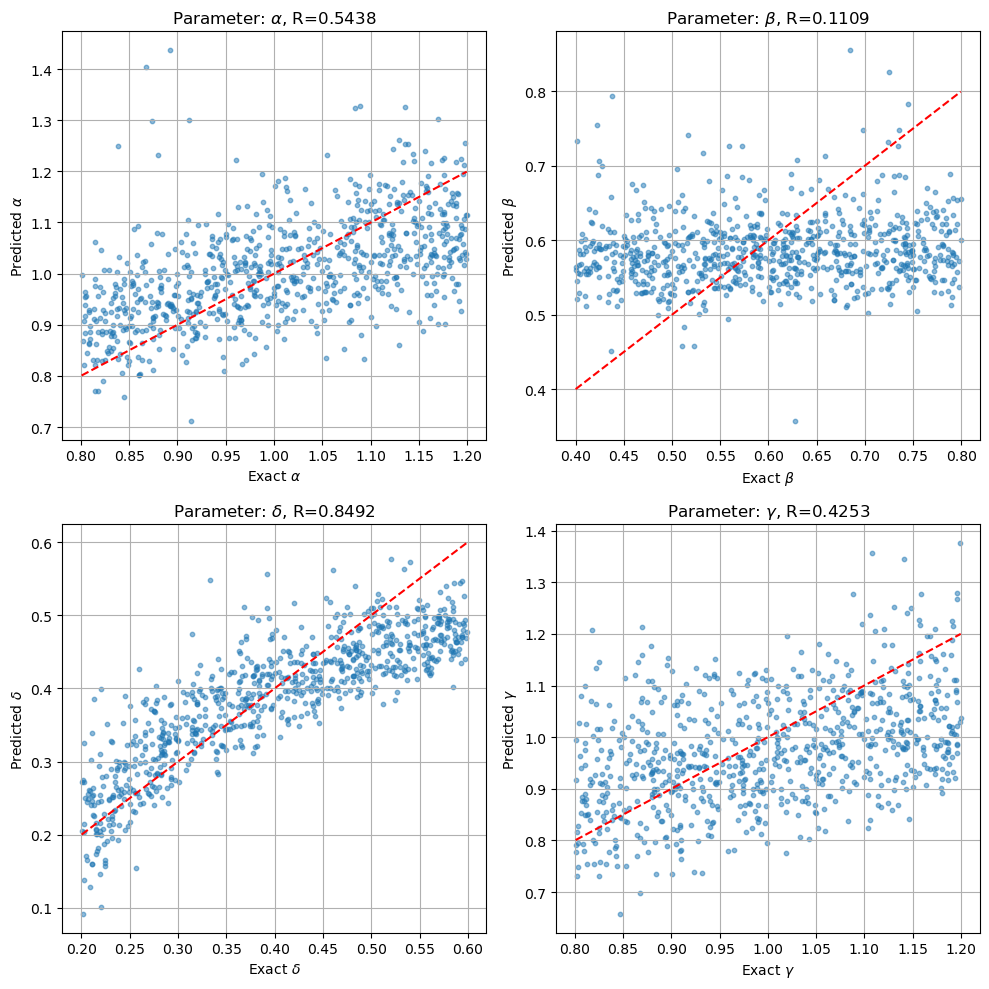

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. 데이터 생성 (Lotka-Volterra Simulator) ---
def lotka_volterra_model(t, y, alpha, beta, delta, gamma):
    x, y_pred = y
    dxdt = alpha * x - beta * x * y_pred
    dydt = delta * x * y_pred - gamma * y_pred
    return [dxdt, dydt]

def generate_lv_data(num_samples=2000):
    """
    무작위 파라미터 쌍에 대해 Lotka-Volterra 모델을 시뮬레이션하고,
    희소한 x(t), y(t) 관측 데이터와 실제 파라미터를 반환합니다.
    """
    param_ranges = {
        'alpha': [0.8, 1.2], 'beta': [0.4, 0.8],
        'delta': [0.2, 0.6], 'gamma': [0.8, 1.2]
    }
    observation_times = np.linspace(0, 20, 10) # 10개 시점 관측
    
    x_observed_data, y_observed_data, params_data = [], [], []

    for _ in range(num_samples):
        params = {k: np.random.uniform(*v) for k, v in param_ranges.items()}
        y0 = [np.random.uniform(5, 15), np.random.uniform(1, 5)]
        
        sol = solve_ivp(
            fun=lotka_volterra_model, t_span=[0, 20], y0=y0,
            args=tuple(params.values()), dense_output=True
        )
        
        observed_trajectory = sol.sol(observation_times)
        x_observed_data.append(observed_trajectory[0])
        y_observed_data.append(observed_trajectory[1])
        params_data.append(list(params.values()))
        
    return (np.array(x_observed_data), np.array(y_observed_data), np.array(params_data))

# --- 2. 모델 정의 ---
# f_theta: 숨겨진 변수(포식자 y)를 예측
class PredatorPredictor(nn.Module):
    def __init__(self, num_obs_points=10, num_params=4):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_obs_points + num_params, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, num_obs_points) # 출력: 10개 시점의 y(t) 값
        )
    def forward(self, x_observed, params):
        # 입력: [x_observed, params]
        combined_input = torch.cat((x_observed, params), dim=1)
        return self.network(combined_input)

# g_phi: 파라미터를 예측
class ParameterEstimator(nn.Module):
    def __init__(self, num_obs_points=10, num_params=4):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_obs_points * 2, 128), # 입력: x(t)와 y(t) 시계열
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_params) # 출력: 4개 파라미터
        )
    def forward(self, x_observed, y_observed):
        combined_input = torch.cat((x_observed, y_observed), dim=1)
        return self.network(combined_input)

# --- 3. 학습 및 평가 ---
if __name__ == '__main__':
    # 하이퍼파라미터
    NUM_SAMPLES = 4000
    TEST_SPLIT = 0.2
    BATCH_SIZE = 128
    EPOCHS = 100
    LEARNING_RATE = 1e-4
    ITERATIONS = 5 # 테스트 시 반복 횟수

    # 1. 데이터셋 생성 및 준비
    print("데이터 생성 중...")
    X_obs, Y_obs, P_true = generate_lv_data(NUM_SAMPLES)
    X_tensor = torch.tensor(X_obs, dtype=torch.float32)
    Y_tensor = torch.tensor(Y_obs, dtype=torch.float32)
    P_tensor = torch.tensor(P_true, dtype=torch.float32)
    
    dataset = TensorDataset(X_tensor, Y_tensor, P_tensor)
    train_size = int((1 - TEST_SPLIT) * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
    
    # 2. 모델, 손실함수, 옵티마이저 초기화
    f_theta = PredatorPredictor()
    g_phi = ParameterEstimator()
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(list(f_theta.parameters()) + list(g_phi.parameters()), lr=LEARNING_RATE)

    # 3. 학습 루프
    print("모델 학습 시작...")
    for epoch in range(EPOCHS):
        for x_batch, y_batch, p_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
            # 두 네트워크를 동시에 학습
            optimizer.zero_grad()
            
            # Loss 1: f_theta가 실제 파라미터로 y를 얼마나 잘 예측하는가
            y_pred_f = f_theta(x_batch, p_batch)
            loss_f = loss_fn(y_pred_f, y_batch)
            
            # Loss 2: g_phi가 실제 데이터로 파라미터를 얼마나 잘 예측하는가
            p_pred_g = g_phi(x_batch, y_batch)
            loss_g = loss_fn(p_pred_g, p_batch)
            
            total_loss = loss_f + loss_g # 두 Loss를 합쳐서 최적화
            total_loss.backward()
            optimizer.step()
    
    # 4. 평가 (고정점 반복법 사용)
    print("모델 평가 중...")
    f_theta.eval()
    g_phi.eval()
    
    all_p_true = []
    all_p_pred_iterative = []
    
    # 테스트 데이터의 평균 파라미터를 초기 추정치로 사용
    p_initial_guess = P_tensor[train_dataset.indices].mean(dim=0).unsqueeze(0)

    with torch.no_grad():
        for x_batch, _, p_batch in test_loader:
            p_n = p_initial_guess.repeat(x_batch.size(0), 1)
            
            # 고정점 반복 시작
            for _ in range(ITERATIONS):
                y_hat = f_theta(x_batch, p_n)   # 현재 p로 y 추정
                p_n = g_phi(x_batch, y_hat)     # 추정된 y로 p 업데이트
            
            all_p_pred_iterative.append(p_n.numpy())
            all_p_true.append(p_batch.numpy())

    p_true_np = np.concatenate(all_p_true)
    p_pred_np = np.concatenate(all_p_pred_iterative)

    # 5. 결과 시각화
    param_names = ['$\\alpha$', '$\\beta$', '$\\delta$', '$\\gamma$']
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    for i in range(4):
        r_val = np.corrcoef(p_true_np[:, i], p_pred_np[:, i])[0, 1]
        axes[i].scatter(p_true_np[:, i], p_pred_np[:, i], alpha=0.5, s=10)
        axes[i].plot([p_true_np[:, i].min(), p_true_np[:, i].max()], [p_true_np[:, i].min(), p_true_np[:, i].max()], 'r--')
        axes[i].set_xlabel(f"Exact {param_names[i]}")
        axes[i].set_ylabel(f"Predicted {param_names[i]}")
        axes[i].set_title(f"Parameter: {param_names[i]}, R={r_val:.4f}")
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()

In [3]:
def analyze_spectral_norms(model, model_name):
    """
    주어진 모델의 각 Linear 레이어의 스펙트럴 노름을 계산하고 출력합니다.
    """
    print(f"\n--- Analyzing Spectral Norms for {model_name} ($f_{'{theta}' if 'f' in model_name else '{phi}'}$) ---")
    
    spectral_norms = []
    # nn.Sequential 내의 각 레이어를 순회합니다.
    for i, layer in enumerate(model.network.children()):
        if isinstance(layer, nn.Linear):
            # layer.weight로부터 가중치 행렬을 가져옵니다.
            W = layer.weight
            
            # torch.linalg.norm(W, ord=2)를 사용해 스펙트럴 노름을 계산합니다.
            norm = torch.linalg.norm(W, ord=2).item()
            spectral_norms.append(norm)
            print(f"Layer {i//2 + 1} (Linear): Spectral Norm = {norm:.4f}")
            
    # 모든 레이어의 스펙트럴 노름의 곱을 계산합니다.
    product_of_norms = np.prod(spectral_norms)
    print(f"Product of all norms for {model_name}: {product_of_norms:.4f}")
    
    return product_of_norms

# --- 4-1. 학습된 모델의 스펙트럴 노름 분석 ---
# 평가 코드 블록 내, 시각화 바로 전에 이 부분을 추가합니다.

# f_theta (PredatorPredictor)의 스펙트럴 노름 분석
prod_f = analyze_spectral_norms(f_theta, "f_theta")

# g_phi (ParameterEstimator)의 스펙트럴 노름 분석
prod_g = analyze_spectral_norms(g_phi, "g_phi")

# --- 최종 수렴 조건 값 계산 ---
# 논문의 Theorem 9.1에 해당하는 최종 조건 값을 계산합니다.
total_product = prod_f * prod_g
print("\n" + "="*50)
print(f"Total Product of Spectral Norms (Π ||W_f|| * Π ||W_g||): {total_product:.4f}")

# 수렴 조건 만족 여부를 확인합니다.
if total_product < 1:
    print("✅ The condition for contractive mapping (Total Product < 1) is satisfied.")
else:
    print("⚠️ The condition for contractive mapping (Total Product < 1) is NOT satisfied.")
print("="*50 + "\n")


--- Analyzing Spectral Norms for f_theta ($f_{theta}$) ---
Layer 1 (Linear): Spectral Norm = 2.1730
Layer 2 (Linear): Spectral Norm = 2.5969
Layer 3 (Linear): Spectral Norm = 1.3139
Product of all norms for f_theta: 7.4143

--- Analyzing Spectral Norms for g_phi ($f_{phi}$) ---
Layer 1 (Linear): Spectral Norm = 1.9729
Layer 2 (Linear): Spectral Norm = 1.4670
Layer 3 (Linear): Spectral Norm = 0.8557
Product of all norms for g_phi: 2.4766

Total Product of Spectral Norms (Π ||W_f|| * Π ||W_g||): 18.3620
⚠️ The condition for contractive mapping (Total Product < 1) is NOT satisfied.



데이터 생성 중...
모델 학습 시작...


모델 평가 중...

--- Analyzing Spectral Norms for f_theta ($f_{theta}$) ---
Layer 1 (Linear): Spectral Norm = 2.3793
Layer 2 (Linear): Spectral Norm = 2.4475
Layer 3 (Linear): Spectral Norm = 1.3317
Product of all norms for f_theta: 7.7551

--- Analyzing Spectral Norms for g_phi ($f_{phi}$) ---
Layer 1 (Linear): Spectral Norm = 1.9009
Layer 2 (Linear): Spectral Norm = 1.3325
Layer 3 (Linear): Spectral Norm = 0.9816
Product of all norms for g_phi: 2.4864

Total Product of Spectral Norms (Π ||W_f|| * Π ||W_g||): 19.2823
⚠️ The condition for contractive mapping (Total Product < 1) is NOT satisfied.



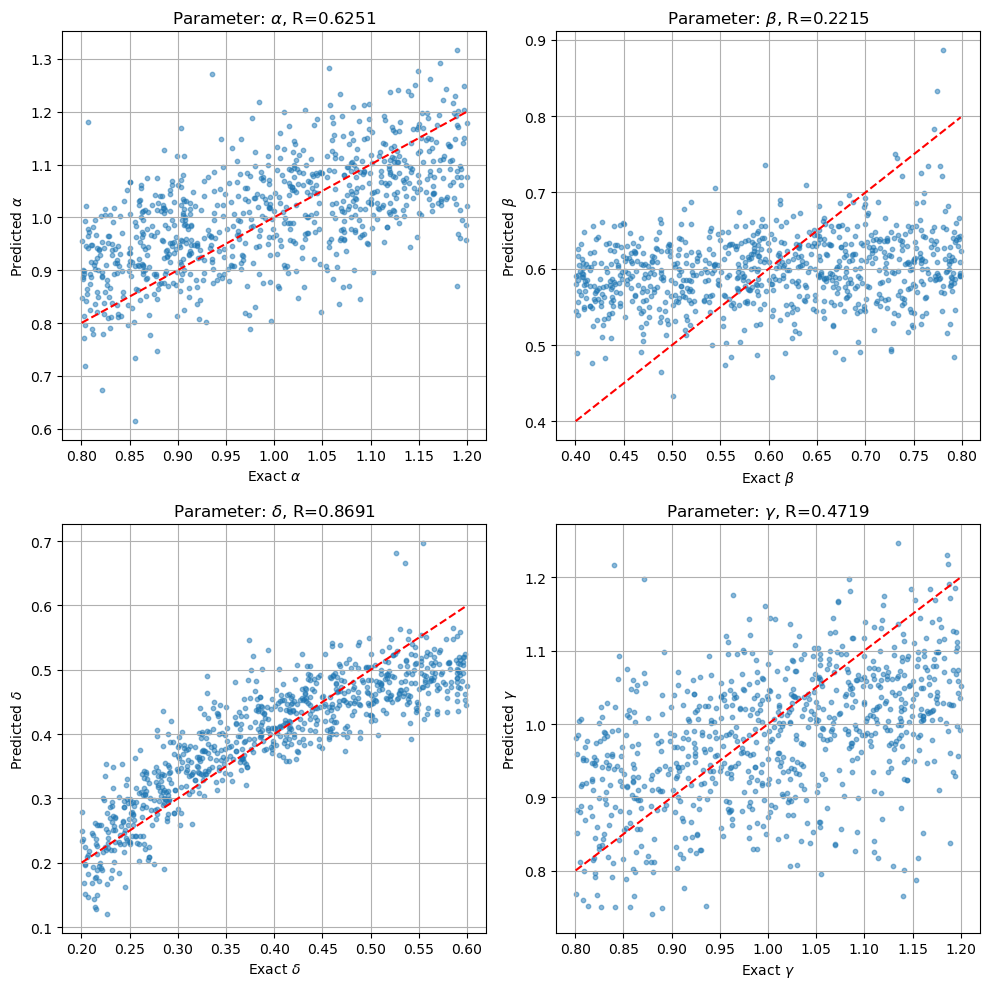

In [4]:

# --- 3. 학습 및 평가 ---
if __name__ == '__main__':
    # 하이퍼파라미터
    NUM_SAMPLES = 4000
    TEST_SPLIT = 0.2
    BATCH_SIZE = 128
    EPOCHS = 100
    LEARNING_RATE = 1e-4
    ITERATIONS = 5 # 테스트 시 반복 횟수
    WEIGHT_DECAY = 1e-5 # 가중치 감쇠 계수 추가

    # 1. 데이터셋 생성 및 준비
    print("데이터 생성 중...")
    X_obs, Y_obs, P_true = generate_lv_data(NUM_SAMPLES)
    X_tensor = torch.tensor(X_obs, dtype=torch.float32)
    Y_tensor = torch.tensor(Y_obs, dtype=torch.float32)
    P_tensor = torch.tensor(P_true, dtype=torch.float32)
    
    dataset = TensorDataset(X_tensor, Y_tensor, P_tensor)
    train_size = int((1 - TEST_SPLIT) * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
    
    # 2. 모델, 손실함수, 옵티마이저 초기화
    f_theta = PredatorPredictor()
    g_phi = ParameterEstimator()
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(list(f_theta.parameters()) + list(g_phi.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # 3. 학습 루프
    print("모델 학습 시작...")
    for epoch in range(EPOCHS):
        for x_batch, y_batch, p_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
            # 두 네트워크를 동시에 학습
            optimizer.zero_grad()
            
            # Loss 1: f_theta가 실제 파라미터로 y를 얼마나 잘 예측하는가
            y_pred_f = f_theta(x_batch, p_batch)
            loss_f = loss_fn(y_pred_f, y_batch)
            
            # Loss 2: g_phi가 실제 데이터로 파라미터를 얼마나 잘 예측하는가
            p_pred_g = g_phi(x_batch, y_batch)
            loss_g = loss_fn(p_pred_g, p_batch)
            
            total_loss = loss_f + loss_g # 두 Loss를 합쳐서 최적화
            total_loss.backward()
            optimizer.step()
    
    # 4. 평가 (고정점 반복법 사용)
    print("모델 평가 중...")
    f_theta.eval()
    g_phi.eval()
    
    all_p_true = []
    all_p_pred_iterative = []
    
    # 테스트 데이터의 평균 파라미터를 초기 추정치로 사용
    p_initial_guess = P_tensor[train_dataset.indices].mean(dim=0).unsqueeze(0)

    with torch.no_grad():
        for x_batch, _, p_batch in test_loader:
            p_n = p_initial_guess.repeat(x_batch.size(0), 1)
            
            # 고정점 반복 시작
            for _ in range(ITERATIONS):
                y_hat = f_theta(x_batch, p_n)   # 현재 p로 y 추정
                p_n = g_phi(x_batch, y_hat)     # 추정된 y로 p 업데이트
            
            all_p_pred_iterative.append(p_n.numpy())
            all_p_true.append(p_batch.numpy())

    p_true_np = np.concatenate(all_p_true)
    p_pred_np = np.concatenate(all_p_pred_iterative)

    # 5. 결과 시각화
        
        # f_theta (PredatorPredictor)의 스펙트럴 노름 분석
    prod_f = analyze_spectral_norms(f_theta, "f_theta")

    # g_phi (ParameterEstimator)의 스펙트럴 노름 분석
    prod_g = analyze_spectral_norms(g_phi, "g_phi")

    # --- 최종 수렴 조건 값 계산 ---
    # 논문의 Theorem 9.1에 해당하는 최종 조건 값을 계산합니다.
    total_product = prod_f * prod_g
    print("\n" + "="*50)
    print(f"Total Product of Spectral Norms (Π ||W_f|| * Π ||W_g||): {total_product:.4f}")

    # 수렴 조건 만족 여부를 확인합니다.
    if total_product < 1:
        print("✅ The condition for contractive mapping (Total Product < 1) is satisfied.")
    else:
        print("⚠️ The condition for contractive mapping (Total Product < 1) is NOT satisfied.")
    print("="*50 + "\n")

    param_names = ['$\\alpha$', '$\\beta$', '$\\delta$', '$\\gamma$']
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    for i in range(4):
        r_val = np.corrcoef(p_true_np[:, i], p_pred_np[:, i])[0, 1]
        axes[i].scatter(p_true_np[:, i], p_pred_np[:, i], alpha=0.5, s=10)
        axes[i].plot([p_true_np[:, i].min(), p_true_np[:, i].max()], [p_true_np[:, i].min(), p_true_np[:, i].max()], 'r--')
        axes[i].set_xlabel(f"Exact {param_names[i]}")
        axes[i].set_ylabel(f"Predicted {param_names[i]}")
        axes[i].set_title(f"Parameter: {param_names[i]}, R={r_val:.4f}")
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()

데이터 생성 중...
모델 학습 시작...


모델 평가 중...

--- Analyzing Spectral Norms for f_theta ($f_{theta}$) ---
Layer 1 (Linear): Spectral Norm = 1.0220
Layer 2 (Linear): Spectral Norm = 1.0325
Layer 3 (Linear): Spectral Norm = 1.0149
Layer 4 (Linear): Spectral Norm = 1.0110
Layer 5 (Linear): Spectral Norm = 1.0667
Layer 6 (Linear): Spectral Norm = 1.0436
Product of all norms for f_theta: 1.2053

--- Analyzing Spectral Norms for g_phi ($f_{phi}$) ---
Layer 1 (Linear): Spectral Norm = 1.0023
Layer 2 (Linear): Spectral Norm = 1.0138
Layer 3 (Linear): Spectral Norm = 1.0051
Layer 4 (Linear): Spectral Norm = 1.0089
Layer 5 (Linear): Spectral Norm = 1.0020
Layer 6 (Linear): Spectral Norm = 1.0030
Layer 7 (Linear): Spectral Norm = 1.0008
Product of all norms for g_phi: 1.0365

Total Product of Spectral Norms (Π ||W_f|| * Π ||W_g||): 1.2493
⚠️ The condition for contractive mapping (Total Product < 1) is NOT satisfied.



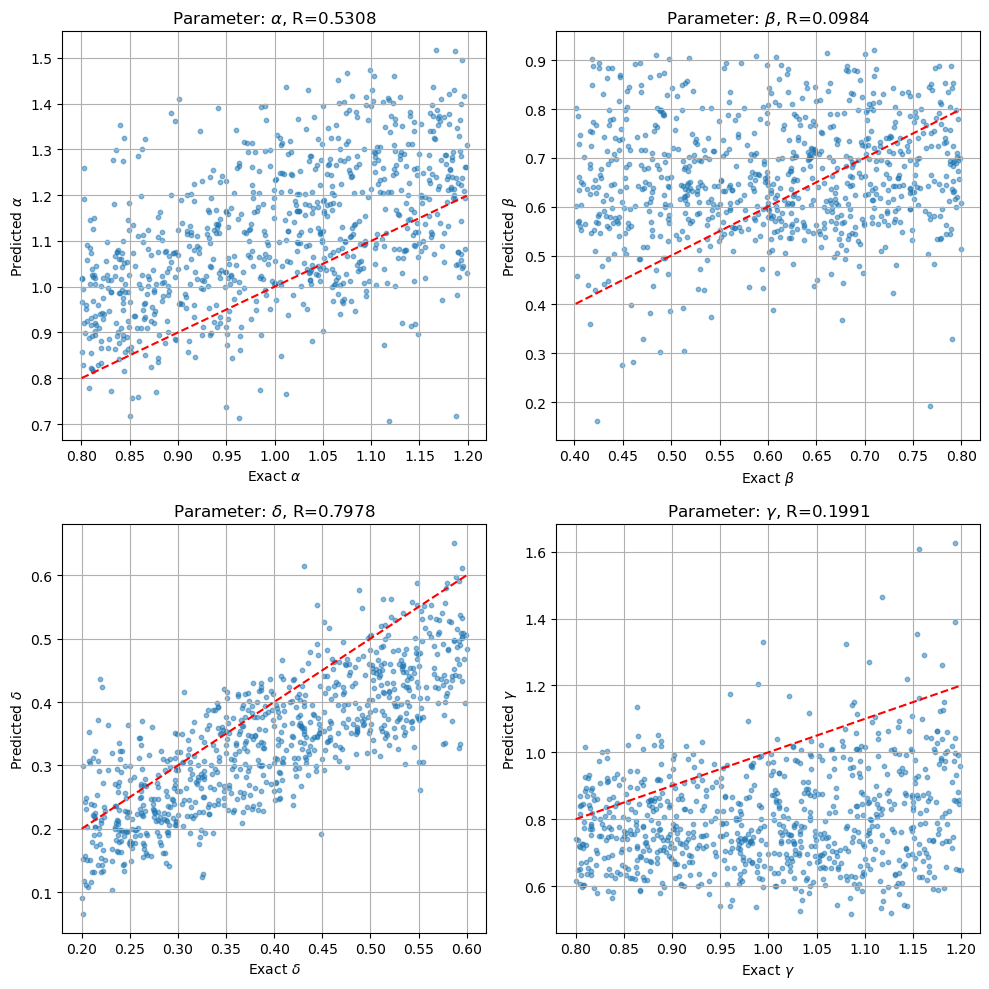

In [12]:
from torch.nn.utils import spectral_norm

# g_phi (ParameterEstimator) 모델 정의 수정
class ParameterEstimator(nn.Module):
    def __init__(self, num_obs_points=10, num_params=4):
        super().__init__()
        self.network = nn.Sequential(
            # 각 Linear 레이어를 spectral_norm으로 감싸줍니다.
            spectral_norm(nn.Linear(num_obs_points * 2, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, num_params))
        )
    # forward 함수는 동일
    def forward(self, x_observed, y_observed):
        combined_input = torch.cat((x_observed, y_observed), dim=1)
        return self.network(combined_input)

# f_theta 모델도 동일하게 수정해줍니다.
# f_theta: 숨겨진 변수(포식자 y)를 예측
class PredatorPredictor(nn.Module):
    def __init__(self, num_obs_points=10, num_params=4):
        super().__init__()
        self.network = nn.Sequential(
            spectral_norm(nn.Linear(num_obs_points + num_params, 64)),
            nn.Tanh(),
            spectral_norm(nn.Linear(64, 64)),
            nn.Tanh(),
            spectral_norm(nn.Linear(64, 64)),
            nn.Tanh(),
            spectral_norm(nn.Linear(64, 64)),
            nn.Tanh(),
            spectral_norm(nn.Linear(64, 64)),
            nn.Tanh(),
            spectral_norm(nn.Linear(64, num_obs_points)) # 출력: 10개 시점의 y(t) 값
        )
    def forward(self, x_observed, params):
        # 입력: [x_observed, params]
        combined_input = torch.cat((x_observed, params), dim=1)
        return self.network(combined_input)

# g_phi: 파라미터를 예측
class ParameterEstimator(nn.Module):
    def __init__(self, num_obs_points=10, num_params=4):
        super().__init__()
        self.network = nn.Sequential(
            spectral_norm(nn.Linear(num_obs_points * 2, 128)), # 입력: x(t)와 y(t) 시계열
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, num_params)) # 출력: 4개 파라미터
        )
    def forward(self, x_observed, y_observed):
        combined_input = torch.cat((x_observed, y_observed), dim=1)
        return self.network(combined_input)
    
    

# --- 3. 학습 및 평가 ---
if __name__ == '__main__':
    # 하이퍼파라미터
    NUM_SAMPLES = 4000
    TEST_SPLIT = 0.2
    BATCH_SIZE = 128
    EPOCHS = 1000
    LEARNING_RATE = 1e-4
    ITERATIONS = 10 # 테스트 시 반복 횟수
    WEIGHT_DECAY = 1e-5 # 가중치 감쇠 계수 추가

    # 1. 데이터셋 생성 및 준비
    print("데이터 생성 중...")
    X_obs, Y_obs, P_true = generate_lv_data(NUM_SAMPLES)
    X_tensor = torch.tensor(X_obs, dtype=torch.float32)
    Y_tensor = torch.tensor(Y_obs, dtype=torch.float32)
    P_tensor = torch.tensor(P_true, dtype=torch.float32)
    
    dataset = TensorDataset(X_tensor, Y_tensor, P_tensor)
    train_size = int((1 - TEST_SPLIT) * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
    
    # 2. 모델, 손실함수, 옵티마이저 초기화
    f_theta = PredatorPredictor()
    g_phi = ParameterEstimator()
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(list(f_theta.parameters()) + list(g_phi.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # 3. 학습 루프
    print("모델 학습 시작...")
    for epoch in range(EPOCHS):
        for x_batch, y_batch, p_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
            # 두 네트워크를 동시에 학습
            optimizer.zero_grad()
            
            # Loss 1: f_theta가 실제 파라미터로 y를 얼마나 잘 예측하는가
            y_pred_f = f_theta(x_batch, p_batch)
            loss_f = loss_fn(y_pred_f, y_batch)
            
            # Loss 2: g_phi가 실제 데이터로 파라미터를 얼마나 잘 예측하는가
            p_pred_g = g_phi(x_batch, y_batch)
            loss_g = loss_fn(p_pred_g, p_batch)
            
            total_loss = loss_f + loss_g # 두 Loss를 합쳐서 최적화
            total_loss.backward()
            optimizer.step()
    
    # 4. 평가 (고정점 반복법 사용)
    print("모델 평가 중...")
    f_theta.eval()
    g_phi.eval()
    
    all_p_true = []
    all_p_pred_iterative = []
    
    # 테스트 데이터의 평균 파라미터를 초기 추정치로 사용
    p_initial_guess = P_tensor[train_dataset.indices].mean(dim=0).unsqueeze(0)

    with torch.no_grad():
        for x_batch, _, p_batch in test_loader:
            p_n = p_initial_guess.repeat(x_batch.size(0), 1)
            
            # 고정점 반복 시작
            for _ in range(ITERATIONS):
                y_hat = f_theta(x_batch, p_n)   # 현재 p로 y 추정
                p_n = g_phi(x_batch, y_hat)     # 추정된 y로 p 업데이트
            
            all_p_pred_iterative.append(p_n.numpy())
            all_p_true.append(p_batch.numpy())

    p_true_np = np.concatenate(all_p_true)
    p_pred_np = np.concatenate(all_p_pred_iterative)

    # 5. 결과 시각화
        
        # f_theta (PredatorPredictor)의 스펙트럴 노름 분석
    prod_f = analyze_spectral_norms(f_theta, "f_theta")

    # g_phi (ParameterEstimator)의 스펙트럴 노름 분석
    prod_g = analyze_spectral_norms(g_phi, "g_phi")

    # --- 최종 수렴 조건 값 계산 ---
    # 논문의 Theorem 9.1에 해당하는 최종 조건 값을 계산합니다.
    total_product = prod_f * prod_g
    print("\n" + "="*50)
    print(f"Total Product of Spectral Norms (Π ||W_f|| * Π ||W_g||): {total_product:.4f}")

    # 수렴 조건 만족 여부를 확인합니다.
    if total_product < 1:
        print("✅ The condition for contractive mapping (Total Product < 1) is satisfied.")
    else:
        print("⚠️ The condition for contractive mapping (Total Product < 1) is NOT satisfied.")
    print("="*50 + "\n")

    param_names = ['$\\alpha$', '$\\beta$', '$\\delta$', '$\\gamma$']
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    for i in range(4):
        r_val = np.corrcoef(p_true_np[:, i], p_pred_np[:, i])[0, 1]
        axes[i].scatter(p_true_np[:, i], p_pred_np[:, i], alpha=0.5, s=10)
        axes[i].plot([p_true_np[:, i].min(), p_true_np[:, i].max()], [p_true_np[:, i].min(), p_true_np[:, i].max()], 'r--')
        axes[i].set_xlabel(f"Exact {param_names[i]}")
        axes[i].set_ylabel(f"Predicted {param_names[i]}")
        axes[i].set_title(f"Parameter: {param_names[i]}, R={r_val:.4f}")
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()

위상 초상 생성 중...


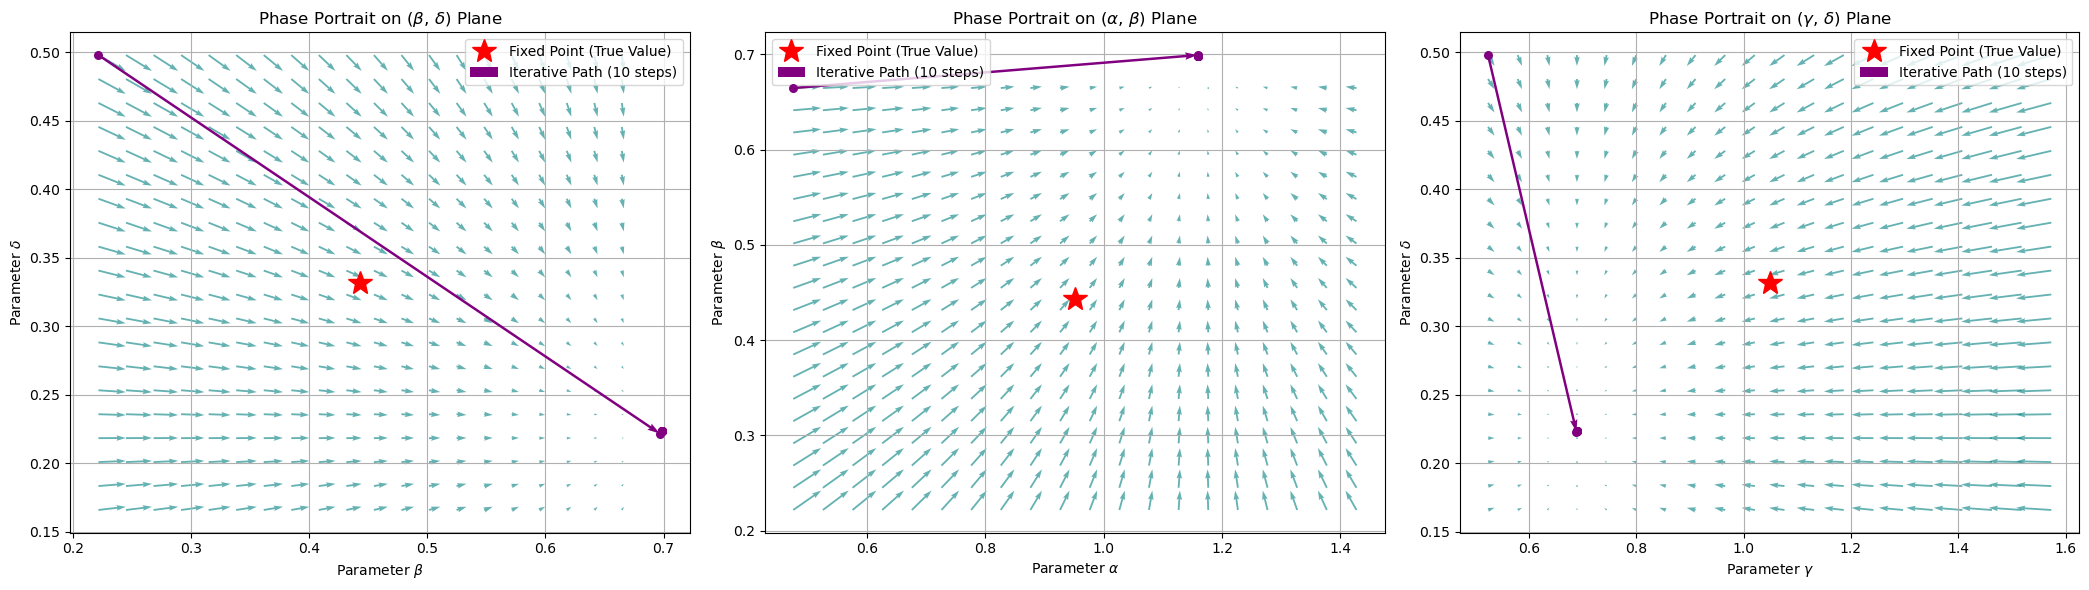

In [13]:
# --- 6. 위상 초상(Phase Portrait) 시각화 ---
# --- plot_phase_portrait 함수 수정 ---

def plot_phase_portrait(ax, f_theta, g_phi, x_observed, true_params, p_dims, p_names, num_iterations=10):
    """
    지정된 2D 파라미터 평면에서 벡터 필드와 함께,
    각 스텝을 화살표로 표현한 최적화 궤적을 그립니다.
    """
    # ... (기존의 격자 생성 및 벡터 필드 시각화 부분은 동일) ...
    p1_range = np.linspace(true_params[p_dims[0]] * 0.5, true_params[p_dims[0]] * 1.5, 20)
    p2_range = np.linspace(true_params[p_dims[1]] * 0.5, true_params[p_dims[1]] * 1.5, 20)
    p1_grid, p2_grid = np.meshgrid(p1_range, p2_range)
    num_grid_points = p1_grid.size
    p0_grid = torch.tensor(true_params, dtype=torch.float32).repeat(num_grid_points, 1)
    p0_grid[:, p_dims[0]] = torch.tensor(p1_grid.flatten(), dtype=torch.float32)
    p0_grid[:, p_dims[1]] = torch.tensor(p2_grid.flatten(), dtype=torch.float32)

    with torch.no_grad():
        x_batch = x_observed.repeat(num_grid_points, 1)
        y_hat = f_theta(x_batch, p0_grid)
        p1_grid_out = g_phi(x_batch, y_hat)
    
    dp = p1_grid_out - p0_grid
    dp_p1 = dp[:, p_dims[0]].numpy()
    dp_p2 = dp[:, p_dims[1]].numpy()

    ax.quiver(p1_grid, p2_grid, dp_p1, dp_p2, color='teal', alpha=0.6, width=0.003)
    ax.plot(true_params[p_dims[0]], true_params[p_dims[1]], 'r*', markersize=18, label='Fixed Point (True Value)', zorder=10)
    
    # --- ✨ 최적화 궤적을 화살표로 시각화 (수정된 부분) ---
    # 1. 궤적의 시작점(p0) 설정
    p_start = torch.tensor(true_params, dtype=torch.float32).unsqueeze(0)
    p_start[0, p_dims[0]] = p1_range[0]
    p_start[0, p_dims[1]] = p2_range[-1]

    # 2. 반복을 통해 궤적 계산
    trajectory = [p_start.clone()]
    p_current = p_start
    with torch.no_grad():
        for _ in range(num_iterations):
            x_batch = x_observed
            y_hat = f_theta(x_batch, p_current)
            p_next = g_phi(x_batch, y_hat)
            trajectory.append(p_next.clone())
            p_current = p_next
    
    traj_np = torch.cat(trajectory).numpy()
    
    # 3. 화살표의 시작점과 벡터 계산
    # 시작점: p0, p1, ..., p_n-1
    starts = traj_np[:-1]
    # 끝점: p1, p2, ..., p_n
    ends = traj_np[1:]
    # 벡터: (p1-p0), (p2-p1), ...
    vectors = ends - starts

    # 4. 궤적을 화살표로 플로팅
    ax.quiver(starts[:, p_dims[0]], starts[:, p_dims[1]], 
              vectors[:, p_dims[0]], vectors[:, p_dims[1]], 
              color='purple', 
              # 이 옵션들이 화살표를 정확한 크기로 그리게 합니다.
              angles='xy', scale_units='xy', scale=1, 
              width=0.004,
              label=f'Iterative Path ({num_iterations} steps)', 
              zorder=5)
              
    # 각 스텝의 '징검다리' 위치를 점으로 표시
    ax.scatter(traj_np[:, p_dims[0]], traj_np[:, p_dims[1]],
               color='purple', s=30, zorder=6)

    ax.set_xlabel(f"Parameter {p_names[0]}")
    ax.set_ylabel(f"Parameter {p_names[1]}")
    ax.set_title(f"Phase Portrait on ({p_names[0]}, {p_names[1]}) Plane")
    ax.legend()
    ax.grid(True)


# --- 메인 코드 블록에 추가 ---
if __name__ == '__main__':
    # ... (기존의 학습, 평가, 스펙트럴 노름 분석 코드) ...

    print("위상 초상 생성 중...")
    # 시각화를 위해 테스트셋에서 하나의 샘플을 선택
    x_sample, _, p_sample = test_dataset[0]
    x_sample = x_sample.unsqueeze(0) # 배치 차원 추가
    true_params_sample = p_sample.numpy()

    # 3개의 위상 초상을 위한 figure 생성
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    # 1. 포식자-피식자 상호작용 평면 (beta vs delta)
    plot_phase_portrait(
        ax=axes[0], f_theta=f_theta, g_phi=g_phi, x_observed=x_sample,
        true_params=true_params_sample, p_dims=(1, 2), p_names=('$\\beta$', '$\\delta$')
    )

    # 2. 피식자 고유 동역학 평면 (alpha vs beta)
    plot_phase_portrait(
        ax=axes[1], f_theta=f_theta, g_phi=g_phi, x_observed=x_sample,
        true_params=true_params_sample, p_dims=(0, 1), p_names=('$\\alpha$', '$\\beta$')
    )
    
    # 3. 포식자 고유 동역학 평면 (gamma vs delta)
    plot_phase_portrait(
        ax=axes[2], f_theta=f_theta, g_phi=g_phi, x_observed=x_sample,
        true_params=true_params_sample, p_dims=(3, 2), p_names=('$\\gamma$', '$\\delta$')
    )

    plt.tight_layout()
    plt.show()

데이터 생성 중...
모델 학습 시작...


모델 평가 중...

--- Analyzing Spectral Norms for f_theta ($f_{theta}$) ---
Layer 1 (Linear): Spectral Norm = 1.0311
Layer 2 (Linear): Spectral Norm = 1.0481
Layer 3 (Linear): Spectral Norm = 1.0347
Layer 4 (Linear): Spectral Norm = 1.0232
Layer 5 (Linear): Spectral Norm = 1.0249
Layer 6 (Linear): Spectral Norm = 1.0192
Product of all norms for f_theta: 1.1953

--- Analyzing Spectral Norms for g_phi ($f_{phi}$) ---
Layer 1 (Linear): Spectral Norm = 1.0070
Layer 2 (Linear): Spectral Norm = 1.0067
Layer 3 (Linear): Spectral Norm = 1.0000
Layer 4 (Linear): Spectral Norm = 1.0003
Layer 5 (Linear): Spectral Norm = 1.0060
Layer 6 (Linear): Spectral Norm = 1.0108
Layer 7 (Linear): Spectral Norm = 1.0033
Product of all norms for g_phi: 1.0347

Total Product of Spectral Norms (Π ||W_f|| * Π ||W_g||): 1.2367
⚠️ The condition for contractive mapping (Total Product < 1) is NOT satisfied.



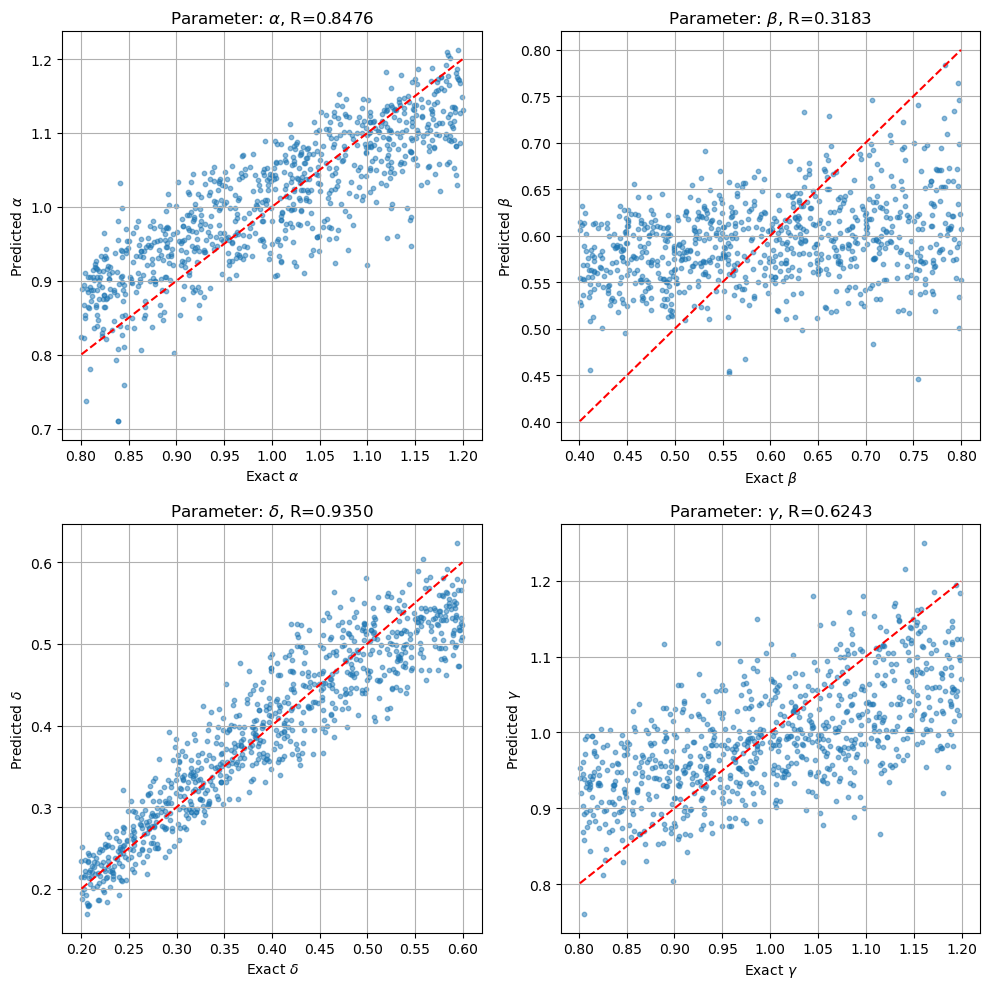

In [14]:
from torch.nn.utils import spectral_norm

# g_phi (ParameterEstimator) 모델 정의 수정
class ParameterEstimator(nn.Module):
    def __init__(self, num_obs_points=10, num_params=4):
        super().__init__()
        self.network = nn.Sequential(
            # 각 Linear 레이어를 spectral_norm으로 감싸줍니다.
            spectral_norm(nn.Linear(num_obs_points * 2, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, num_params))
        )
    # forward 함수는 동일
    def forward(self, x_observed, y_observed):
        combined_input = torch.cat((x_observed, y_observed), dim=1)
        return self.network(combined_input)

# f_theta 모델도 동일하게 수정해줍니다.
# f_theta: 숨겨진 변수(포식자 y)를 예측
class PredatorPredictor(nn.Module):
    def __init__(self, num_obs_points=10, num_params=4):
        super().__init__()
        self.network = nn.Sequential(
            spectral_norm(nn.Linear(num_obs_points + num_params, 64)),
            nn.Tanh(),
            spectral_norm(nn.Linear(64, 64)),
            nn.Tanh(),
            spectral_norm(nn.Linear(64, 64)),
            nn.Tanh(),
            spectral_norm(nn.Linear(64, 64)),
            nn.Tanh(),
            spectral_norm(nn.Linear(64, 64)),
            nn.Tanh(),
            spectral_norm(nn.Linear(64, num_obs_points)) # 출력: 10개 시점의 y(t) 값
        )
    def forward(self, x_observed, params):
        # 입력: [x_observed, params]
        combined_input = torch.cat((x_observed, params), dim=1)
        return self.network(combined_input)

# g_phi: 파라미터를 예측
class ParameterEstimator(nn.Module):
    def __init__(self, num_obs_points=10, num_params=4):
        super().__init__()
        self.network = nn.Sequential(
            spectral_norm(nn.Linear(num_obs_points * 2, 128)), # 입력: x(t)와 y(t) 시계열
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, 128)),
            nn.Tanh(),
            spectral_norm(nn.Linear(128, num_params)) # 출력: 4개 파라미터
        )
    def forward(self, x_observed, y_observed):
        combined_input = torch.cat((x_observed, y_observed), dim=1)
        return self.network(combined_input)
    
    

# --- 3. 학습 및 평가 ---
if __name__ == '__main__':
    # 하이퍼파라미터
    NUM_SAMPLES = 4000
    TEST_SPLIT = 0.2
    BATCH_SIZE = 128
    EPOCHS = 1000
    LEARNING_RATE = 1e-4
    ITERATIONS = 10 # 테스트 시 반복 횟수
    WEIGHT_DECAY = 1e-5 # 가중치 감쇠 계수 추가

    # 1. 데이터셋 생성 및 준비
    print("데이터 생성 중...")
    X_obs, Y_obs, P_true = generate_lv_data(NUM_SAMPLES)
    X_tensor = torch.tensor(X_obs, dtype=torch.float32)
    Y_tensor = torch.tensor(Y_obs, dtype=torch.float32)
    P_tensor = torch.tensor(P_true, dtype=torch.float32)
    
    dataset = TensorDataset(X_tensor, Y_tensor, P_tensor)
    train_size = int((1 - TEST_SPLIT) * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
    
    # 2. 모델, 손실함수, 옵티마이저 초기화
    f_theta = PredatorPredictor()
    g_phi = ParameterEstimator()
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(list(f_theta.parameters()) + list(g_phi.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # 3. 학습 루프
    print("모델 학습 시작...")
    for epoch in range(EPOCHS):
        for x_batch, y_batch, p_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
            # 두 네트워크를 동시에 학습
            optimizer.zero_grad()
            
            # Loss 1: f_theta가 실제 파라미터로 y를 얼마나 잘 예측하는가
            y_pred_f = f_theta(x_batch, p_batch)
            loss_f = loss_fn(y_pred_f, y_batch)
            
            # Loss 2: g_phi가 실제 데이터로 파라미터를 얼마나 잘 예측하는가
            p_pred_g = g_phi(x_batch, y_batch)
            loss_g = loss_fn(p_pred_g, p_batch)
            
            # --- 수정된 total_loss ---
            p_reconstructed = g_phi(x_batch, y_pred_f) # y_pred_f는 f_theta의 출력
            loss_consistency = loss_fn(p_reconstructed, p_batch)

            # lambda는 새로운 손실의 중요도를 조절하는 하이퍼파라미터입니다. (예: 1.0)
            lambda_consistency = 1.0 
            total_loss = loss_f + loss_g + lambda_consistency * loss_consistency
            total_loss.backward()
            optimizer.step()
    
    # 4. 평가 (고정점 반복법 사용)
    print("모델 평가 중...")
    f_theta.eval()
    g_phi.eval()
    
    all_p_true = []
    all_p_pred_iterative = []
    
    # 테스트 데이터의 평균 파라미터를 초기 추정치로 사용
    p_initial_guess = P_tensor[train_dataset.indices].mean(dim=0).unsqueeze(0)

    with torch.no_grad():
        for x_batch, _, p_batch in test_loader:
            p_n = p_initial_guess.repeat(x_batch.size(0), 1)
            
            # 고정점 반복 시작
            for _ in range(ITERATIONS):
                y_hat = f_theta(x_batch, p_n)   # 현재 p로 y 추정
                p_n = g_phi(x_batch, y_hat)     # 추정된 y로 p 업데이트
            
            all_p_pred_iterative.append(p_n.numpy())
            all_p_true.append(p_batch.numpy())

    p_true_np = np.concatenate(all_p_true)
    p_pred_np = np.concatenate(all_p_pred_iterative)

    # 5. 결과 시각화
        
        # f_theta (PredatorPredictor)의 스펙트럴 노름 분석
    prod_f = analyze_spectral_norms(f_theta, "f_theta")

    # g_phi (ParameterEstimator)의 스펙트럴 노름 분석
    prod_g = analyze_spectral_norms(g_phi, "g_phi")

    # --- 최종 수렴 조건 값 계산 ---
    # 논문의 Theorem 9.1에 해당하는 최종 조건 값을 계산합니다.
    total_product = prod_f * prod_g
    print("\n" + "="*50)
    print(f"Total Product of Spectral Norms (Π ||W_f|| * Π ||W_g||): {total_product:.4f}")

    # 수렴 조건 만족 여부를 확인합니다.
    if total_product < 1:
        print("✅ The condition for contractive mapping (Total Product < 1) is satisfied.")
    else:
        print("⚠️ The condition for contractive mapping (Total Product < 1) is NOT satisfied.")
    print("="*50 + "\n")

    param_names = ['$\\alpha$', '$\\beta$', '$\\delta$', '$\\gamma$']
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()

    for i in range(4):
        r_val = np.corrcoef(p_true_np[:, i], p_pred_np[:, i])[0, 1]
        axes[i].scatter(p_true_np[:, i], p_pred_np[:, i], alpha=0.5, s=10)
        axes[i].plot([p_true_np[:, i].min(), p_true_np[:, i].max()], [p_true_np[:, i].min(), p_true_np[:, i].max()], 'r--')
        axes[i].set_xlabel(f"Exact {param_names[i]}")
        axes[i].set_ylabel(f"Predicted {param_names[i]}")
        axes[i].set_title(f"Parameter: {param_names[i]}, R={r_val:.4f}")
        axes[i].grid(True)
    
    plt.tight_layout()
    plt.show()

위상 초상 생성 중...


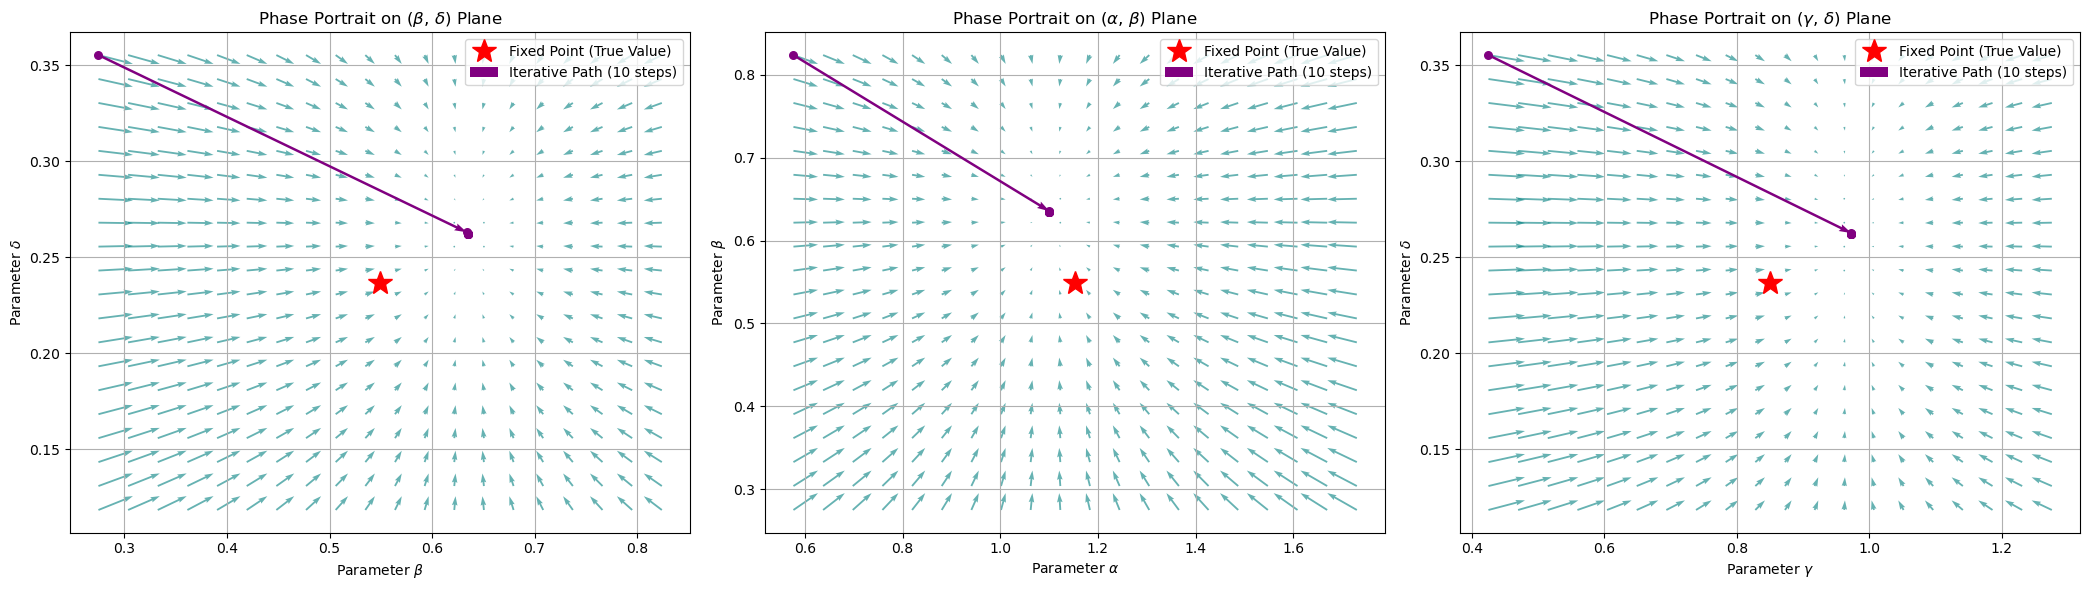

In [15]:
# --- 6. 위상 초상(Phase Portrait) 시각화 ---
# --- plot_phase_portrait 함수 수정 ---

def plot_phase_portrait(ax, f_theta, g_phi, x_observed, true_params, p_dims, p_names, num_iterations=10):
    """
    지정된 2D 파라미터 평면에서 벡터 필드와 함께,
    각 스텝을 화살표로 표현한 최적화 궤적을 그립니다.
    """
    # ... (기존의 격자 생성 및 벡터 필드 시각화 부분은 동일) ...
    p1_range = np.linspace(true_params[p_dims[0]] * 0.5, true_params[p_dims[0]] * 1.5, 20)
    p2_range = np.linspace(true_params[p_dims[1]] * 0.5, true_params[p_dims[1]] * 1.5, 20)
    p1_grid, p2_grid = np.meshgrid(p1_range, p2_range)
    num_grid_points = p1_grid.size
    p0_grid = torch.tensor(true_params, dtype=torch.float32).repeat(num_grid_points, 1)
    p0_grid[:, p_dims[0]] = torch.tensor(p1_grid.flatten(), dtype=torch.float32)
    p0_grid[:, p_dims[1]] = torch.tensor(p2_grid.flatten(), dtype=torch.float32)

    with torch.no_grad():
        x_batch = x_observed.repeat(num_grid_points, 1)
        y_hat = f_theta(x_batch, p0_grid)
        p1_grid_out = g_phi(x_batch, y_hat)
    
    dp = p1_grid_out - p0_grid
    dp_p1 = dp[:, p_dims[0]].numpy()
    dp_p2 = dp[:, p_dims[1]].numpy()

    ax.quiver(p1_grid, p2_grid, dp_p1, dp_p2, color='teal', alpha=0.6, width=0.003)
    ax.plot(true_params[p_dims[0]], true_params[p_dims[1]], 'r*', markersize=18, label='Fixed Point (True Value)', zorder=10)
    
    # --- ✨ 최적화 궤적을 화살표로 시각화 (수정된 부분) ---
    # 1. 궤적의 시작점(p0) 설정
    p_start = torch.tensor(true_params, dtype=torch.float32).unsqueeze(0)
    p_start[0, p_dims[0]] = p1_range[0]
    p_start[0, p_dims[1]] = p2_range[-1]

    # 2. 반복을 통해 궤적 계산
    trajectory = [p_start.clone()]
    p_current = p_start
    with torch.no_grad():
        for _ in range(num_iterations):
            x_batch = x_observed
            y_hat = f_theta(x_batch, p_current)
            p_next = g_phi(x_batch, y_hat)
            trajectory.append(p_next.clone())
            p_current = p_next
    
    traj_np = torch.cat(trajectory).numpy()
    
    # 3. 화살표의 시작점과 벡터 계산
    # 시작점: p0, p1, ..., p_n-1
    starts = traj_np[:-1]
    # 끝점: p1, p2, ..., p_n
    ends = traj_np[1:]
    # 벡터: (p1-p0), (p2-p1), ...
    vectors = ends - starts

    # 4. 궤적을 화살표로 플로팅
    ax.quiver(starts[:, p_dims[0]], starts[:, p_dims[1]], 
              vectors[:, p_dims[0]], vectors[:, p_dims[1]], 
              color='purple', 
              # 이 옵션들이 화살표를 정확한 크기로 그리게 합니다.
              angles='xy', scale_units='xy', scale=1, 
              width=0.004,
              label=f'Iterative Path ({num_iterations} steps)', 
              zorder=5)
              
    # 각 스텝의 '징검다리' 위치를 점으로 표시
    ax.scatter(traj_np[:, p_dims[0]], traj_np[:, p_dims[1]],
               color='purple', s=30, zorder=6)

    ax.set_xlabel(f"Parameter {p_names[0]}")
    ax.set_ylabel(f"Parameter {p_names[1]}")
    ax.set_title(f"Phase Portrait on ({p_names[0]}, {p_names[1]}) Plane")
    ax.legend()
    ax.grid(True)


# --- 메인 코드 블록에 추가 ---
if __name__ == '__main__':
    # ... (기존의 학습, 평가, 스펙트럴 노름 분석 코드) ...

    print("위상 초상 생성 중...")
    # 시각화를 위해 테스트셋에서 하나의 샘플을 선택
    x_sample, _, p_sample = test_dataset[0]
    x_sample = x_sample.unsqueeze(0) # 배치 차원 추가
    true_params_sample = p_sample.numpy()

    # 3개의 위상 초상을 위한 figure 생성
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    # 1. 포식자-피식자 상호작용 평면 (beta vs delta)
    plot_phase_portrait(
        ax=axes[0], f_theta=f_theta, g_phi=g_phi, x_observed=x_sample,
        true_params=true_params_sample, p_dims=(1, 2), p_names=('$\\beta$', '$\\delta$')
    )

    # 2. 피식자 고유 동역학 평면 (alpha vs beta)
    plot_phase_portrait(
        ax=axes[1], f_theta=f_theta, g_phi=g_phi, x_observed=x_sample,
        true_params=true_params_sample, p_dims=(0, 1), p_names=('$\\alpha$', '$\\beta$')
    )
    
    # 3. 포식자 고유 동역학 평면 (gamma vs delta)
    plot_phase_portrait(
        ax=axes[2], f_theta=f_theta, g_phi=g_phi, x_observed=x_sample,
        true_params=true_params_sample, p_dims=(3, 2), p_names=('$\\gamma$', '$\\delta$')
    )

    plt.tight_layout()
    plt.show()